---

# LABORATORY OF CHAPTER 2: DATA CLEANING AND IMPUTATION

---

<BR><br>

---

## Chapter 1: Addressing Missing Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('Resources/planes.csv')
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882.0
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0
2,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0
3,SpiceJet,24/06/2019,Kolkata,Banglore,CCU → BLR,09:00,11:25,2h 25m,non-stop,No info,3873.0
4,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,18:55,10:25 13 Mar,15h 30m,1 stop,In-flight meal not included,11087.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10660 entries, 0 to 10659
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          10233 non-null  object 
 1   Date_of_Journey  10338 non-null  object 
 2   Source           10473 non-null  object 
 3   Destination      10313 non-null  object 
 4   Route            10404 non-null  object 
 5   Dep_Time         10400 non-null  object 
 6   Arrival_Time     10466 non-null  object 
 7   Duration         10446 non-null  object 
 8   Total_Stops      10448 non-null  object 
 9   Additional_Info  10071 non-null  object 
 10  Price            10044 non-null  float64
dtypes: float64(1), object(10)
memory usage: 916.2+ KB


<br><br>

---

<span style='color:orange'>

### 1. Print the number of missing values in each column of the DataFrame.

In [4]:
df.isna().sum()

Airline            427
Date_of_Journey    322
Source             187
Destination        347
Route              256
Dep_Time           260
Arrival_Time       194
Duration           214
Total_Stops        212
Additional_Info    589
Price              616
dtype: int64

<br><br>

---

<span style='color:orange'>

### 2. Calculate how many observations five percent of the planes DataFrame is equal to.

In [5]:
threshold = int(len(df) * 0.05)
threshold

533

<br><br>

---

<span style='color:orange'>

### 3. Create `cols_to_drop` by applying boolean indexing to columns of the DataFrame with missing values less than or equal to the threshold.

In [6]:
# step 3:
cols_to_drop = df.columns[df.isna().sum() <= threshold]
cols_to_drop

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops'],
      dtype='object')

<br><br>

---

<span style='color:orange'>

### 4. Use this filter to remove missing values and save the updated DataFrame.

In [7]:
# Step 4:
df.dropna(subset=cols_to_drop, inplace=True)

# Now let's check the results of dropping nan values <= 5% (dataset)
df.isna().sum()

Airline              0
Date_of_Journey      0
Source               0
Destination          0
Route                0
Dep_Time             0
Arrival_Time         0
Duration             0
Total_Stops          0
Additional_Info    300
Price              368
dtype: int64

<br><br>

---

<span style='color:orange'>

### 5. Print the values and frequencies of `Additional_Info`.

In [8]:
df.Additional_Info.value_counts()

Additional_Info
No info                         6399
In-flight meal not included     1525
No check-in baggage included     258
1 Long layover                    14
Change airports                    7
No Info                            2
Business class                     1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

<br><br>

---

<span style='color:orange'>

### 6. Create a boxplot of `Price` versus `Airline`.

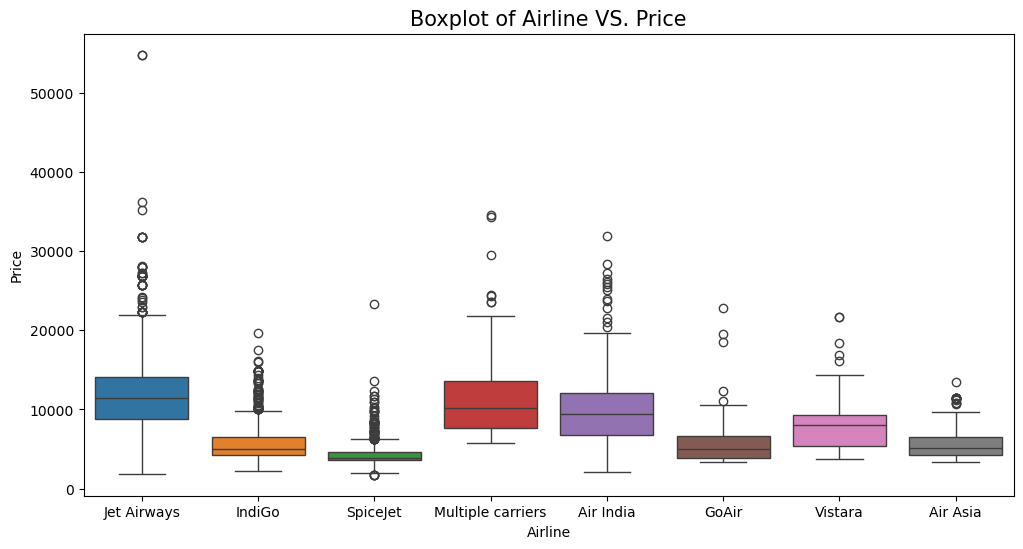

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Airline', y='Price', hue='Airline')

plt.title('Boxplot of Airline VS. Price', fontsize=15)
plt.show()

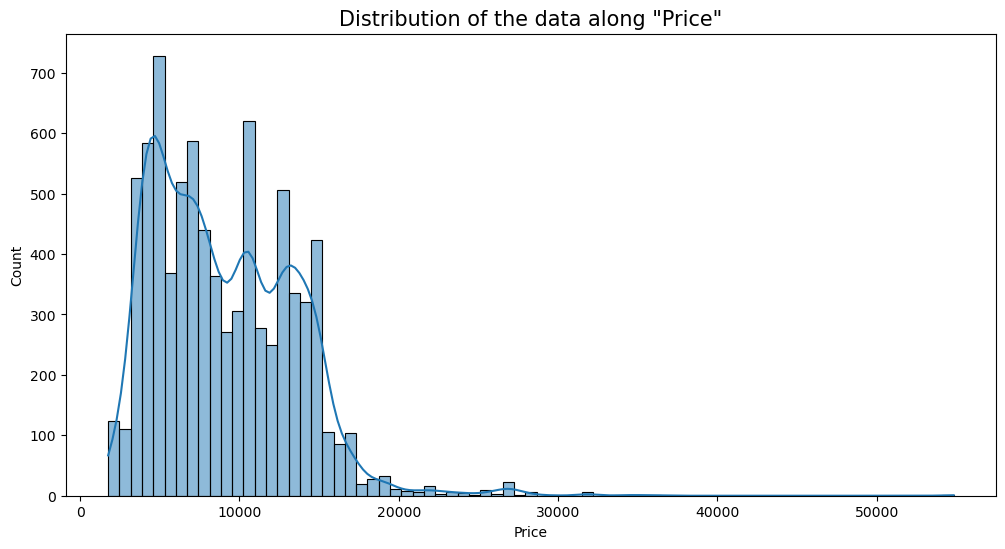

In [10]:
# Lets take a look at the distribution of "Price"
plt.figure(figsize=(12,6))
sns.histplot(data=df, x='Price', kde=True)
plt.title('Distribution of the data along "Price"', fontsize=15)
plt.show()

<br><br>

---

<span style='color:orange'>

### 7. Remove the `Additional_Info` Column

In [11]:
df = df.drop(labels='Additional_Info', axis=1)
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Price
0,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,13882.0
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,6218.0
2,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,13302.0
3,SpiceJet,24/06/2019,Kolkata,Banglore,CCU → BLR,09:00,11:25,2h 25m,non-stop,3873.0
4,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,18:55,10:25 13 Mar,15h 30m,1 stop,11087.0


<br><br>

---

<span style='color:orange'>

### 8. Group the DataFrame by `Airline` and calculate the "Median" `Price`.

In [12]:
airline_price = df.groupby('Airline')['Price'].median()
airline_price

Airline
Air Asia              5192.0
Air India             9443.0
GoAir                 5003.5
IndiGo                5054.0
Jet Airways          11507.0
Multiple carriers    10197.0
SpiceJet              3873.0
Vistara               8028.0
Name: Price, dtype: float64

In [13]:
# Save the indexes of all NAN Values for "Price" for double check
df_na_idx = df[df['Price'].isna() == True].index
df_na_idx

Index([   60,    76,    89,    99,   121,   154,   179,   197,   199,   232,
       ...
       10429, 10470, 10472, 10507, 10508, 10531, 10571, 10578, 10585, 10653],
      dtype='int64', length=368)

<br><br>

---

<span style='color:orange'>

### 9. Convert the grouped median to a dictionary

In [14]:
prices_dict = airline_price.to_dict()
prices_dict

{'Air Asia': 5192.0,
 'Air India': 9443.0,
 'GoAir': 5003.5,
 'IndiGo': 5054.0,
 'Jet Airways': 11507.0,
 'Multiple carriers': 10197.0,
 'SpiceJet': 3873.0,
 'Vistara': 8028.0}

<br><br>

---

<span style='color:orange'>

### 10. Conditionally impute missing values for `Price` by mapping values in the `Airline` column based on `prices_dict`.

In [15]:
# Lets see the NaN values on "Price", before Imputation
df.loc[df_na_idx]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Price
60,Multiple carriers,3/06/2019,Delhi,Cochin,DEL → BOM → COK,08:45,19:00,10h 15m,1 stop,NaN
76,Jet Airways,15/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,12:35 16 Jun,19h 5m,1 stop,NaN
89,Multiple carriers,6/03/2019,Delhi,Cochin,DEL → BOM → COK,02:15,13:20,11h 5m,1 stop,NaN
99,Jet Airways,9/06/2019,Kolkata,Banglore,CCU → BOM → BLR,20:00,08:15 10 Jun,12h 15m,1 stop,NaN
121,Air India,1/03/2019,Delhi,Cochin,DEL → BOM → COK,23:00,19:15 02 Mar,20h 15m,1 stop,NaN
...,...,...,...,...,...,...,...,...,...,...
10531,Jet Airways,6/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,05:30,19:00,13h 30m,2 stops,NaN
10571,Jet Airways,27/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,12:35 28 Jun,13h 30m,2 stops,NaN
10578,Multiple carriers,6/03/2019,Delhi,Cochin,DEL → BOM → COK,10:20,21:00,10h 40m,1 stop,NaN
10585,Jet Airways,12/05/2019,Kolkata,Banglore,CCU → BOM → BLR,06:30,04:40 13 May,22h 10m,1 stop,NaN


In [16]:
#df['Price'] = 
df['Price'] = df['Price'].fillna(df['Airline'].map(prices_dict))

In [17]:
# Now lets check how this imputation worked
df.loc[df_na_idx]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Price
60,Multiple carriers,3/06/2019,Delhi,Cochin,DEL → BOM → COK,08:45,19:00,10h 15m,1 stop,10197.0
76,Jet Airways,15/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,12:35 16 Jun,19h 5m,1 stop,11507.0
89,Multiple carriers,6/03/2019,Delhi,Cochin,DEL → BOM → COK,02:15,13:20,11h 5m,1 stop,10197.0
99,Jet Airways,9/06/2019,Kolkata,Banglore,CCU → BOM → BLR,20:00,08:15 10 Jun,12h 15m,1 stop,11507.0
121,Air India,1/03/2019,Delhi,Cochin,DEL → BOM → COK,23:00,19:15 02 Mar,20h 15m,1 stop,9443.0
...,...,...,...,...,...,...,...,...,...,...
10531,Jet Airways,6/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,05:30,19:00,13h 30m,2 stops,11507.0
10571,Jet Airways,27/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,12:35 28 Jun,13h 30m,2 stops,11507.0
10578,Multiple carriers,6/03/2019,Delhi,Cochin,DEL → BOM → COK,10:20,21:00,10h 40m,1 stop,10197.0
10585,Jet Airways,12/05/2019,Kolkata,Banglore,CCU → BOM → BLR,06:30,04:40 13 May,22h 10m,1 stop,11507.0


<br><br>

---

<span style='color:orange'>

### 11. Lets take a final check for missing values

In [18]:
df.isna().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Price              0
dtype: int64

<br><br>

---
---

<br><br>